# In Python, a class definition has the following format

Although you should note that you can mix the order of the definition of attri
butes, and methods as required within a single class.


In [ ]:
class Person:
  def __init__(self, name: str, age: int):
    self.name = name
    self.age = age
  def __str__(self):
    print (self.name,self.age)
    return self.name + ' is ' + str(self.age)

New instances/objects (examples) of the class Person can be created by using the
name of the class and passing in the values to be used for the parameters of the
initialisation method (with the exception of the first parameter self which is pro
vided automatically by Python).

For example, the following creates two instances of the class Person:

The two variables reference separate instances or examples of the class
Person. They therefore respond to the same set of methods/operations and have
the same set of attributes (such as name and age); however, they have their own
values for those attributes (such as 'John' and 'Phoebe').

Each instance also has its own unique identifier—that shows that even if the
attribute values happen to be the same between two objects (for example there
happen to be two people called John who are both 36); they are still separate
instances of the given class. This identifier can be accessed using the id()
function, for example

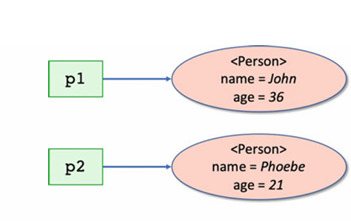

In [ ]:
p1 = Person("Yogesh",40)
print(id(p1))

p2 = Person("Sam",18)
print(id(p2))

print(p1)
print(p2)

132274864441152
132274900902080
Yogesh 40
Yogesh is 40
Sam 18
Sam is 18


# **Be Careful with Assignment**

Given that in the above example, p1 and p2 reference different instances of the
class Person; what happens when p1 or p2 are assigned to another variable? That
is, what happens in this case:

In [ ]:
class Person:
  def __init__(self, name: str, age: int):
    self.name = name
    self.age = age
  def __str__(self):
    print (self.name,self.age)
    return self.name + ' is ' + str(self.age)

p1 = Person('Yogesh', 40)
px = p1

What does px reference? Actually, it makes a complete copy of the value held
by p1; however, p1 does not hold the instance of the class Person; it holds the
address of the object. It thus copies the address held in p1 into the variable px. This
means that both p1 and px now reference (point at) the same instance in memory;
we there have this:

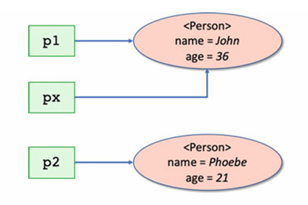

In [ ]:
print(p1)
print(px)

Yogesh 40
Yogesh is 40
Yogesh 40
Yogesh is 40


Inheritance allows features defined in one class to be inherited and reused in the
definition of another class. For example, a Person class might have the attributes
name and age. It might also have behaviour associated with a Person such as
birthday().

We might then decide that we want to have another class Employee and that
employees also have a name and an age and will have birthdays. However, in
addition an Employee may have an employee Id attribute and a calculate_pay() behaviour.

At this point we could duplicate the definition of the name and age attributes
and the birthday() behaviour in the class Employee (for example by cutting
and pasting the code between the two classes).

However, this is not only inefficient; it may also cause problems in the future.

For example we may realise that there is a problem or bug in the implementation of
birthday() and may correct it in the class Person; however, we may forget to
apply the same fix to the class Employee.

In general, in software design and development it is considered best practice to
define something once and to reuse that something when required.

In an object-oriented system we can achieve the reuse of data or behaviour via
inheritance. That is one class (in this case the Employee class) can inherit features
from another class (in this case Person).

This is shown pictorially below:

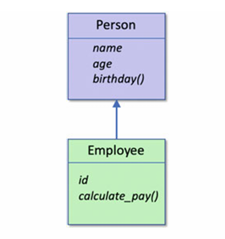

In this diagram the Employee class  is shown as inheriting from the Person class.

This means that the Employee class obtains all the data and behaviour of the Person
class. It is therefore as though the Employee class has defined three attributes name,
age and id and two methods birthday() and calculate_pay().

A class that is defined as extending a parent class has the following syntax:

class SubClassName(BaseClassName):

class-body

Note that the parent class is specified by providing the name of that class in
round brackets after the name of the new (child) class.

We can define the class Person in Python as before

In [ ]:
class Person:
  def __init__(self, name, age):
    self.name = name
    self.age = age
  def birthday(self):
    print('Happy birthday you were', self.age)
    self.age += 1
    print('You are now', self.age)

We could now define the class Employee as being a class whose definition
builds on (or inherits from) the class Person:


In [ ]:
class Employee(Person):
  def __init__(self, name, age, id):
    super().__init__(name, age)
    self.id = id
  def calculate_pay(self, hours_worked):
    rate_of_pay = 7.50
    if self.age >= 21:
      rate_of_pay += 2.50
    return hours_worked * rate_of_pay

Here we do several things:

1. The class is called Employee but it extends Person. This is indicated by
including the name of the class being inherited in parentheses after the name of
the class being defined (e.g. Employee(Person)) in the class declaration.

2. Inside the __init __ method we reference the __init __() method
defined in the class Person and used to initialise instances of that class (via the
super().__init __() reference. This allows whatever initialisation is
required for Person to happen. This is called from within the Employee
class’s __init __() which then allows any initialisation required by the
Employee to occur. Note that the call to the super().__init __() ini
tialiser can come anywhere within the Employee.__init __() method; but
by convention it comes first to ensure that whatever the Person class does
during initialisation does not over write what happens in the Employee class.

3. All instances of the class Person have a name, and age and have the
behaviour birthday().

4. All instances of the class Employee have a name,andage and an id and have
the behaviours birthday() and calculate_pay(house_worked).

5. The method calculate_pay() defined in the Employee class can access
the attributes name and age just as it can access the attribute id. In fact, it uses
the employee’s age to determine the rate of pay to apply.

We can go further, and we can subclass Employee, for example with the class
SalesPerson

In [ ]:
class SalesPerson(Employee):
  def __init__(self, name, age, id, region, sales):
    super().__init__(name, age, id)
    self.region = region
    self.sales = sales
  def bonus(self):
    return self.sales * 0.5

Now we can say that the class SalesPerson has a name,an age and an id
as well as a region and a sales total. It also has the methods birthday(),
calculate_pay(hourse_worked) and bonus().

In this case the SalesPerson.__init __() method calls the Employee.

__init __() method as that is the next class up the hierarchy and thus we want to
run that classes initialisation behaviour before we set up the SalesPerson class
(which of course in turn runs the Person classes initialisation behaviour).

We can now write code such as:

In [ ]:
print('Person')
p = Person('John', 54)
print(p)
print('-' * 25)

Person
-------------------------


In [ ]:
print('Employee')
e = Employee('Denise', 51, 7468)
e.birthday()
print('e.calculate_pay(40):', e.calculate_pay(40))
print('-' * 25)

Employee
Happy birthday you were 51
You are now 52
e.calculate_pay(40): 400.0
-------------------------


In [ ]:
print('SalesPerson')
s = SalesPerson('Phoebe', 21, 4712, 'UK', 30000.0)
s.birthday()
print('s.calculate_pay(40):', s.calculate_pay(40))
print('s.bonus():', s.bonus())

SalesPerson
Happy birthday you were 21
You are now 22
s.calculate_pay(40): 400.0
s.bonus(): 15000.0


In [ ]:
print('Person')
p = Person('John', 54)
print(p)
print('-' * 25)
print('Employee')
e = Employee('Denise', 51, 7468)
e.birthday()
print('e.calculate_pay(40):', e.calculate_pay(40))
print('-' * 25)
print('SalesPerson')
s = SalesPerson('Phoebe', 21, 4712, 'UK', 30000.0)
s.birthday()
print('s.calculate_pay(40):', s.calculate_pay(40))
print('s.bonus():', s.bonus())

Person
-------------------------
Employee
Happy birthday you were 51
You are now 52
e.calculate_pay(40): 400.0
-------------------------
SalesPerson
Happy birthday you were 21
You are now 22
s.calculate_pay(40): 400.0
s.bonus(): 15000.0


# Person Class Recap

Let us bring together the concepts that we have looked at so far in the final version
of the class Person.

In [ ]:
class Person:
 def __init__(self, name, age):
  self.name = name
  self.age = age
 def __str__(self):
  return self.name + ' is ' + str(self.age)
 def birthday(self):
  print ('Happy birthday you were', self.age)
  self.age += 1
  print('You are now', self.age)
 def calculate_pay(self, hours_worked):
  rate_of_pay = 7.50
  if self.age >= 21:
    rate_of_pay += 2.50
    return hours_worked * rate_of_pay
 def is_teenager(self):
  return self.age < 20

p1 = Person('John', 36)
print(p1)
print (p1.name, 'is', p1.age)
print('p1.is_teenager', p1.is_teenager())
p1.birthday()
print(p1)
p1.age = 18
print(p1)

John is 36
John is 36
p1.is_teenager False
Happy birthday you were 36
You are now 37
John is 37
John is 18


# The del Keyword

Having at one point created an object of some type (whether that is a bool,anint
or a user defined type such as Person) it may later be necessary to delete that
object. This can be done using the keyword del. This keyword is used to delete
objects which allows the memory they are using to be reclaimed and used by other
parts of your program.

In [ ]:
p1 = Person('John', 36)
print(p1)
del p1

John 36
John is 36


NameError: name 'p1' is not defined

# Intrinsic Attributes

Every class (and every object) in Python has a set of intrinsic attributes set up by
the Python runtime system. Some of these intrinsic attributes are given below for
classes and objects.

Classes have the following intrinsic attributes:

• __name __ the name of the class

• __module __ the module (or library) from which it was loaded

• __bases __ a collection of its base classes (see inheritance later in this book)

• __dict __ a dictionary (a set of key-value pairs) containing all the attributes
(including methods)

• __doc __ the documentation string.

For objects:

• __class __ the name of the class of the object

• __dict __ a dictionary containing all the object’s attributes.

Notice that these intrinsic attributes all start and end with a double underbar—
this indicates their special status within Python.

An example of printing these attributes out for the class Person and a instance
of the class are shown below

In [ ]:
print('Class attributes')
print(Person.__name__)
print(Person.__module__)
print(Person.__doc__)
print(Person.__dict__)
print('Object attributes')
print(p1.__class__)
print(p1.__dict__)

Class attributes
Person
__main__
None
{'__module__': '__main__', '__init__': <function Person.__init__ at 0x7e6324b39300>, '__str__': <function Person.__str__ at 0x7e6324b393a0>, 'birthday': <function Person.birthday at 0x7e6324b39440>, 'calculate_pay': <function Person.calculate_pay at 0x7e6324b394e0>, 'is_teenager': <function Person.is_teenager at 0x7e6324b39580>, '__dict__': <attribute '__dict__' of 'Person' objects>, '__weakref__': <attribute '__weakref__' of 'Person' objects>, '__doc__': None}
Object attributes
<class '__main__.Person'>
{'name': 'John', 'age': 18}
